<a href="https://colab.research.google.com/github/apekshamore175/VEHICLE-COUNT-PREDICTION-FROM-SENSOR-DATA/blob/main/VehicalCount.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# VEHICLE COUNT PREDICTION FROM SENSOR DATA
# ============================================================
# Dataset: Search "Metro Interstate Traffic Volume" on Kaggle
# Run on: Google Colab
# ============================================================

# STEP 1 — Install & Import Libraries
# ============================================================
# Run this in Colab first:
# !pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

In [5]:
# ============================================================
# STEP 2 — Load Dataset
# ============================================================
df = pd.read_csv('/content/Metro_Interstate_Traffic_Volume.csv')

In [6]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nNull Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Shape: (48204, 9)

Columns: ['traffic_volume', 'holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time']

First 5 rows:
   traffic_volume holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0            5545     NaN  288.28      0.0      0.0          40       Clouds   
1            4516     NaN  289.36      0.0      0.0          75       Clouds   
2            4767     NaN  289.58      0.0      0.0          90       Clouds   
3            5026     NaN  290.13      0.0      0.0          90       Clouds   
4            4918     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description         date_time  
0    scattered clouds  02-10-2012 09:00  
1       broken clouds  02-10-2012 10:00  
2     overcast clouds  02-10-2012 11:00  
3     overcast clouds  02-10-2012 12:00  
4       broken clouds  02-10-2012 13:00  

Null Values:
traffic_volume             0
holiday                48143
temp                      

In [7]:
# ============================================================
# STEP 3 — Data Cleaning
# ============================================================
# Drop duplicates
df.drop_duplicates(inplace=True)



In [8]:
# Drop null rows
df.dropna(inplace=True)



In [9]:
# Convert date_time to datetime format
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')

print("\nAfter cleaning shape:", df.shape)
print("\nTraffic Volume stats:")
print(df['traffic_volume'].describe())


After cleaning shape: (61, 9)

Traffic Volume stats:
count      61.000000
mean      865.442623
std       291.028952
min       455.000000
25%       615.000000
50%       812.000000
75%      1041.000000
max      1538.000000
Name: traffic_volume, dtype: float64


In [10]:

# ============================================================
# STEP 4 — Feature Engineering (Time Based Features)
# ============================================================
df['hour']        = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek   # 0=Monday, 6=Sunday
df['month']       = df['date_time'].dt.month
df['year']        = df['date_time'].dt.year
df['is_weekend']  = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['is_rush_hour']= df['hour'].apply(
    lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 19) else 0)


In [11]:
# Encode weather columns
le = LabelEncoder()
df['weather_encoded']      = le.fit_transform(df['weather_main'].astype(str))
df['weather_desc_encoded'] = le.fit_transform(df['weather_description'].astype(str))


In [12]:


# Drop original datetime and text columns
df.drop(['date_time', 'weather_main', 'weather_description'], axis=1, inplace=True)

print("\nFeature engineered columns:")
print(df.columns.tolist())
print("\nFirst 5 rows after feature engineering:")
print(df.head())


Feature engineered columns:
['traffic_volume', 'holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_rush_hour', 'weather_encoded', 'weather_desc_encoded']

First 5 rows after feature engineering:
      traffic_volume           holiday    temp  rain_1h  snow_1h  clouds_all  \
126              455      Columbus Day  273.08      0.0      0.0          20   
1123            1000      Veterans Day  288.12      0.0      0.0          87   
1370             919  Thanksgiving Day  278.54      0.0      0.0          20   
2360             803     Christmas Day  264.40      0.0      0.0          90   
2559            1439     New Years Day  263.49      0.0      0.0          58   

      hour  day_of_week  month  year  is_weekend  is_rush_hour  \
126      0            0     10  2012           0             0   
1123     0            0     11  2012           0             0   
1370     0            3     11  2012           0             0  

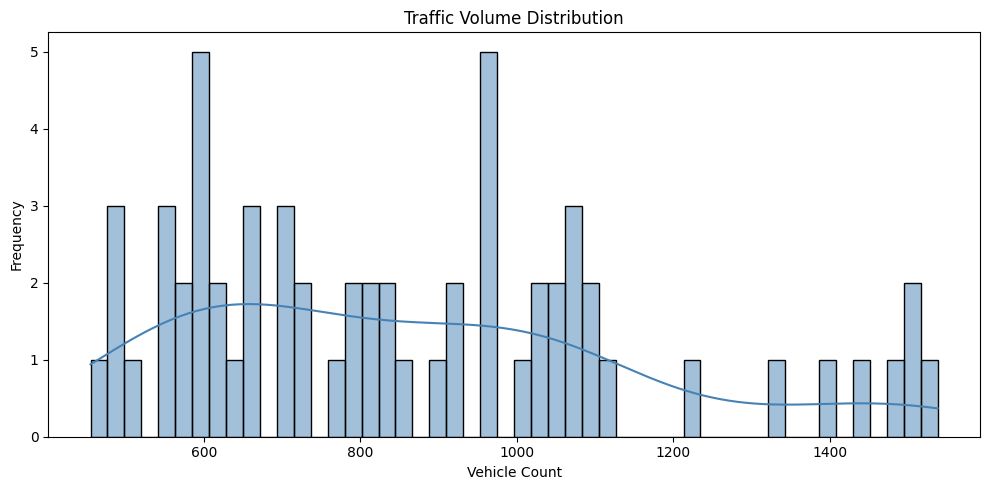

In [13]:

# ============================================================
# STEP 5 — EDA Visualizations
# ============================================================

# 1. Traffic Volume Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['traffic_volume'], bins=50, color='steelblue', kde=True)
plt.title('Traffic Volume Distribution')
plt.xlabel('Vehicle Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

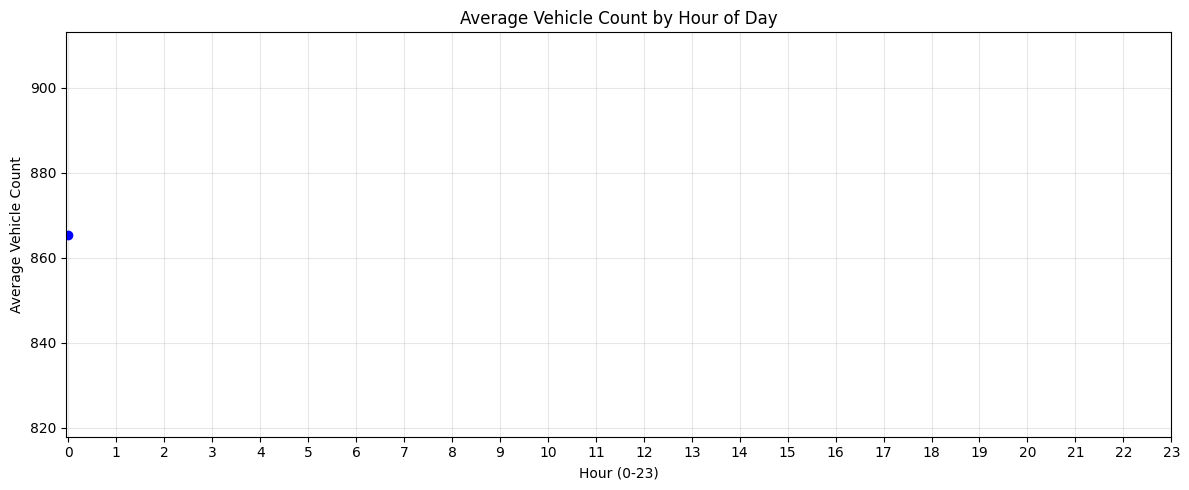

In [14]:
# 2. Average Traffic by Hour of Day
plt.figure(figsize=(12, 5))
df.groupby('hour')['traffic_volume'].mean().plot(
    kind='line', marker='o', color='blue', linewidth=2)
plt.title('Average Vehicle Count by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Average Vehicle Count')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


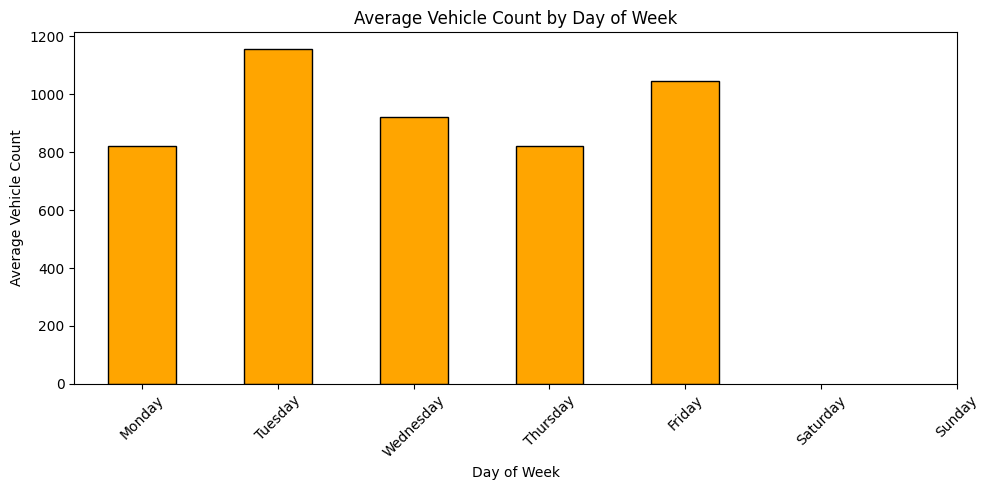

In [15]:
# 3. Average Traffic by Day of Week
plt.figure(figsize=(10, 5))
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df.groupby('day_of_week')['traffic_volume'].mean().plot(
    kind='bar', color='orange', edgecolor='black')
plt.title('Average Vehicle Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Vehicle Count')
plt.xticks(range(7), days, rotation=45)
plt.tight_layout()
plt.show()


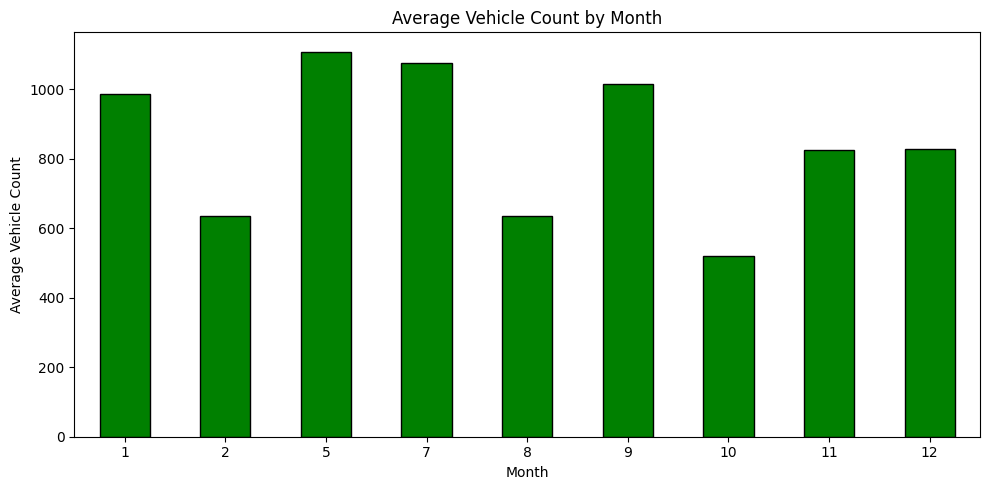

In [16]:
# 4. Average Traffic by Month
plt.figure(figsize=(10, 5))
df.groupby('month')['traffic_volume'].mean().plot(
    kind='bar', color='green', edgecolor='black')
plt.title('Average Vehicle Count by Month')
plt.xlabel('Month')
plt.ylabel('Average Vehicle Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

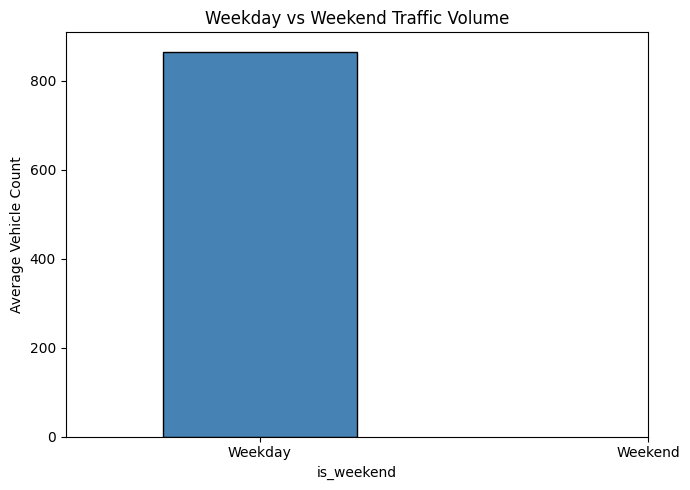

In [17]:
# 5. Weekday vs Weekend Traffic
plt.figure(figsize=(7, 5))
df.groupby('is_weekend')['traffic_volume'].mean().plot(
    kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Weekday vs Weekend Traffic Volume')
plt.xticks([0, 1], ['Weekday', 'Weekend'], rotation=0)
plt.ylabel('Average Vehicle Count')
plt.tight_layout()
plt.show()


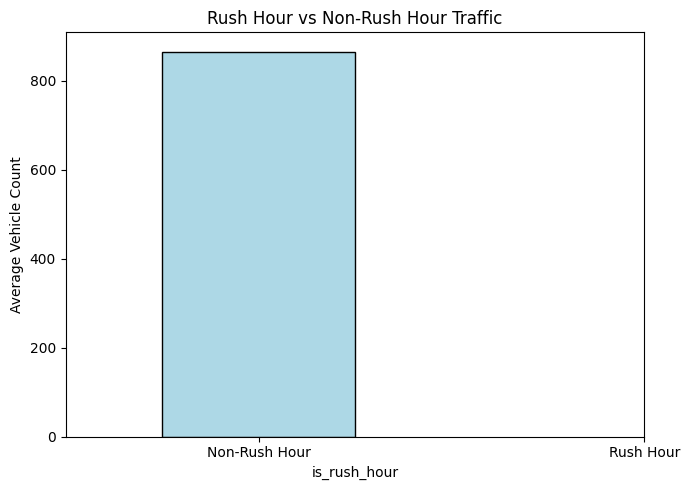

In [18]:
# 6. Rush Hour vs Non-Rush Hour
plt.figure(figsize=(7, 5))
df.groupby('is_rush_hour')['traffic_volume'].mean().plot(
    kind='bar', color=['lightblue', 'darkblue'], edgecolor='black')
plt.title('Rush Hour vs Non-Rush Hour Traffic')
plt.xticks([0, 1], ['Non-Rush Hour', 'Rush Hour'], rotation=0)
plt.ylabel('Average Vehicle Count')
plt.tight_layout()
plt.show()

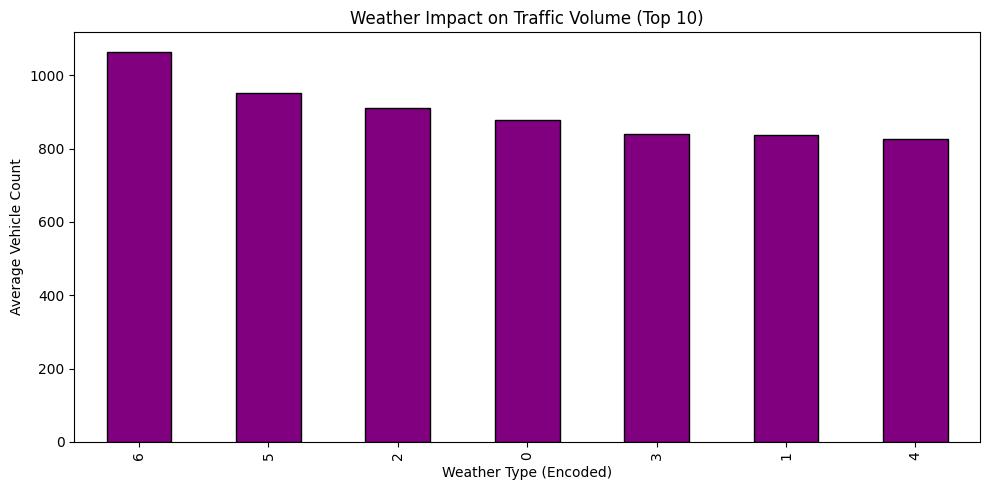

In [19]:
# 7. Weather Impact on Traffic
plt.figure(figsize=(10, 5))
df.groupby('weather_encoded')['traffic_volume'].mean().sort_values(
    ascending=False)[:10].plot(kind='bar', color='purple', edgecolor='black')
plt.title('Weather Impact on Traffic Volume (Top 10)')
plt.xlabel('Weather Type (Encoded)')
plt.ylabel('Average Vehicle Count')
plt.tight_layout()
plt.show()

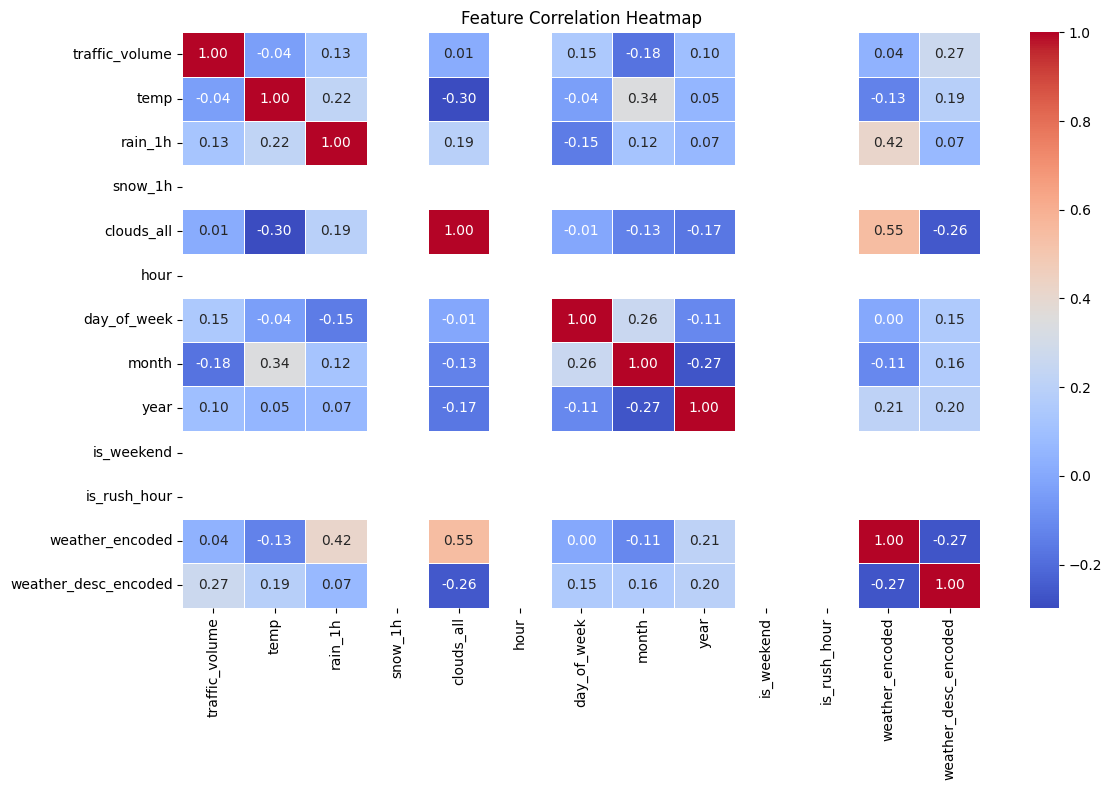

In [20]:
# ============================================================
# STEP 6 — Correlation Heatmap
# ============================================================
plt.figure(figsize=(12, 8))
# Drop 'holiday' column for correlation calculation as it contains string values
corr = df.drop('holiday', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# STEP 7 — Prepare Features & Target
# ============================================================
features = ['hour', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour',
            'weather_encoded', 'temp', 'rain_1h', 'snow_1h', 'clouds_all']

# Keep only existing columns
features = [f for f in features if f in df.columns]

X = df[features]
y = df['traffic_volume']

print("\nFeatures used:", features)
print("X shape:", X.shape)
print("y shape:", y.shape)



Features used: ['hour', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'weather_encoded', 'temp', 'rain_1h', 'snow_1h', 'clouds_all']
X shape: (61, 10)
y shape: (61,)


In [22]:
# ============================================================
# STEP 8 — Train Test Split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("\nTraining size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (48, 10)
Testing size: (13, 10)


In [23]:
# ============================================================
# STEP 9 — Model Building
# ============================================================

# --- Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [24]:
# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [25]:
# --- XGBoost ---
xgb = XGBRegressor(n_estimators=100, random_state=42,
                   learning_rate=0.1, max_depth=6)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [26]:
# ============================================================
# STEP 10 — Evaluation
# ============================================================
def evaluate_model(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f"\n--- {name} ---")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAE  : {mae:.2f}")
    print(f"R2   : {r2:.4f}")
    return rmse, mae, r2

lr_rmse,  lr_mae,  lr_r2  = evaluate_model("Linear Regression", y_test, lr_pred)
rf_rmse,  rf_mae,  rf_r2  = evaluate_model("Random Forest",     y_test, rf_pred)
xgb_rmse, xgb_mae, xgb_r2 = evaluate_model("XGBoost",          y_test, xgb_pred)


--- Linear Regression ---
RMSE : 303.44
MAE  : 270.23
R2   : -0.4492

--- Random Forest ---
RMSE : 268.26
MAE  : 206.88
R2   : -0.1327

--- XGBoost ---
RMSE : 437.52
MAE  : 294.35
R2   : -2.0130


/tmp/ipykernel_428/3494563257.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


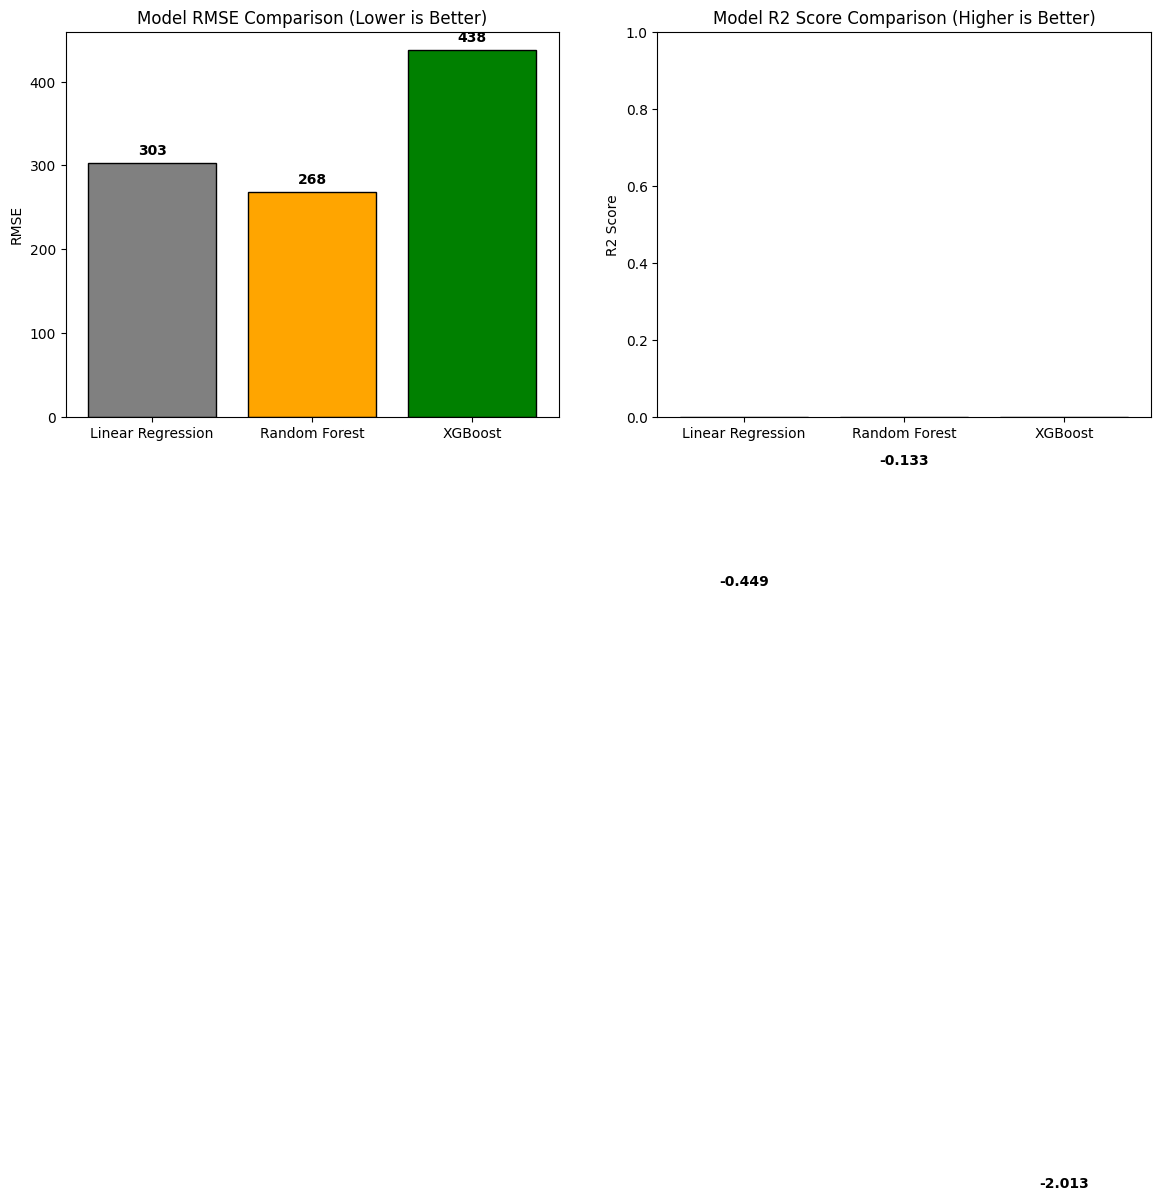

In [27]:
# ============================================================
# STEP 11 — Model Comparison Chart
# ============================================================
models     = ['Linear Regression', 'Random Forest', 'XGBoost']
rmse_scores = [lr_rmse, rf_rmse, xgb_rmse]
r2_scores   = [lr_r2,   rf_r2,   xgb_r2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(models, rmse_scores, color=['gray', 'orange', 'green'], edgecolor='black')
axes[0].set_title('Model RMSE Comparison (Lower is Better)')
axes[0].set_ylabel('RMSE')
for i, v in enumerate(rmse_scores):
    axes[0].text(i, v + 10, f"{v:.0f}", ha='center', fontweight='bold')

axes[1].bar(models, r2_scores, color=['gray', 'orange', 'green'], edgecolor='black')
axes[1].set_title('Model R2 Score Comparison (Higher is Better)')
axes[1].set_ylabel('R2 Score')
axes[1].set_ylim(0, 1)
for i, v in enumerate(r2_scores):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

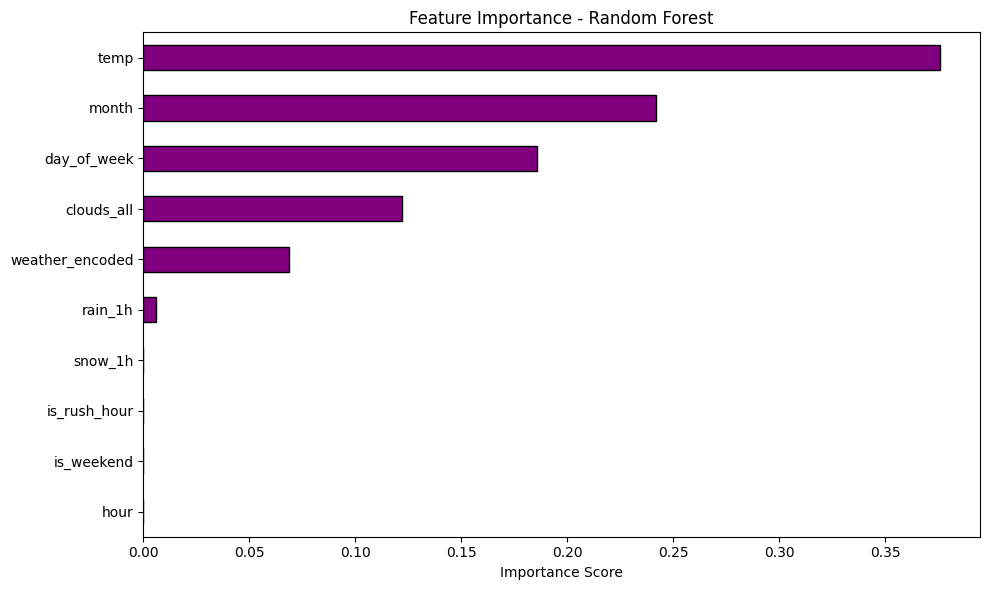


Top Features:
temp               0.375853
month              0.241955
day_of_week        0.185757
clouds_all         0.122074
weather_encoded    0.068606
rain_1h            0.005755
hour               0.000000
is_weekend         0.000000
is_rush_hour       0.000000
snow_1h            0.000000
dtype: float64


In [28]:
# ============================================================
# STEP 12 — Feature Importance (Random Forest)
# ============================================================
feat_imp = pd.Series(rf.feature_importances_, index=features)
feat_imp_sorted = feat_imp.sort_values()

plt.figure(figsize=(10, 6))
feat_imp_sorted.plot(kind='barh', color='purple', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop Features:")
print(feat_imp.sort_values(ascending=False))

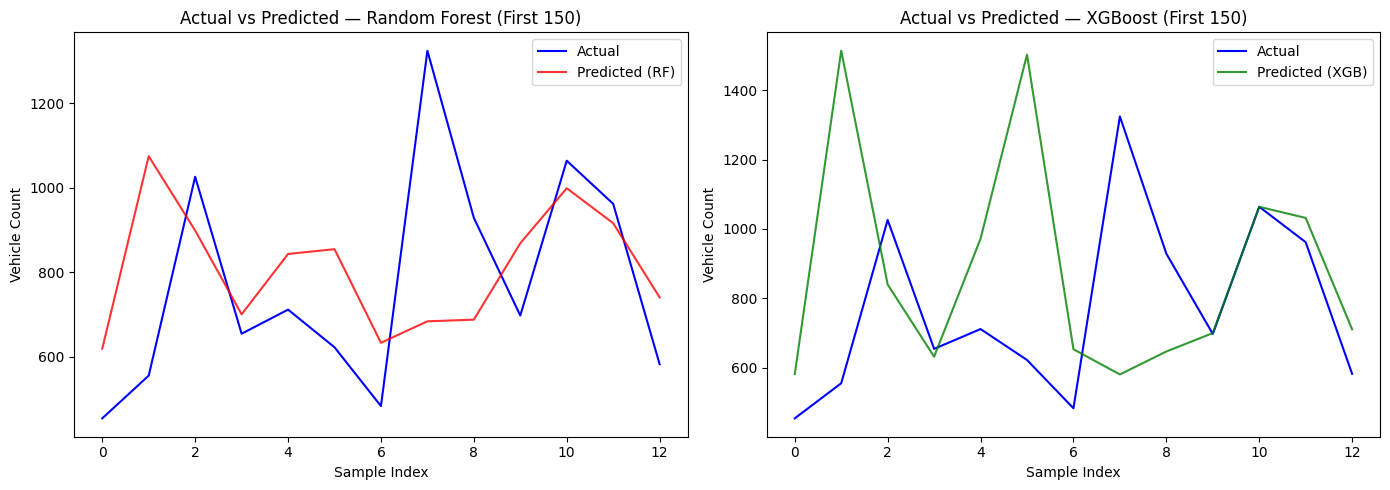


✅ Vehicle Count Prediction Complete!


In [29]:
# ============================================================
# STEP 13 — Actual vs Predicted Plot
# ============================================================
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(y_test.values[:150], label='Actual', color='blue', linewidth=1.5)
plt.plot(rf_pred[:150], label='Predicted (RF)', color='red',
         linewidth=1.5, alpha=0.8)
plt.title('Actual vs Predicted — Random Forest (First 150)')
plt.xlabel('Sample Index')
plt.ylabel('Vehicle Count')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_test.values[:150], label='Actual', color='blue', linewidth=1.5)
plt.plot(xgb_pred[:150], label='Predicted (XGB)', color='green',
         linewidth=1.5, alpha=0.8)
plt.title('Actual vs Predicted — XGBoost (First 150)')
plt.xlabel('Sample Index')
plt.ylabel('Vehicle Count')
plt.legend()

plt.tight_layout()
plt.show()

print("\n✅ Vehicle Count Prediction Complete!")